# Contexto

Este es un cuaderno de código creado para la capacitación de [ARSET](https://www.earthdata.nasa.gov/data/projects/arset) "[Estimación de PM<sub>2.5</sub> en la Superficie Usando Datos de Satélites y Otras Fuentes de Información](https://www.earthdata.nasa.gov/es/learn/trainings/estimacion-de-pm2.5-en-la-superficie-usando-datos-de-satelites-y-otras-fuentes-de)". El propósito es ilustrar cómo extraer datos de productos satelitales de PM<sub>2.5</sub> existentes para una región de interés determinada y compararlos con datos de mediciones de PM<sub>2.5</sub> obtenidas en superficie.

**Esta versión del cuaderno está destinada a utilizarse en la tarea.**

Autores:  
*   Carl Malings / Morgan State University & NASA Goddard Space Flight Center
*   Sebastián Diez / Centro de Investigación en Tecnologías para la Sociedad, Universidad del Desarrollo (Chile)


# Setup

Estos son los pasos de preparación necesarios para el caso de estudio:

1.   Copia este cuaderno a un lugar en tu Google Drive.
  -   Selecciona: Archivo > Guardar una copia en Drive
  -   Sugiero crear una carpeta nueva para almacenar todos los códigos y datos de este caso de estudio, para mantener tu Drive organizado. Nombré mi carpeta `PM25_Training_2026` y la coloqué dentro de mi Drive en `/content/drive/MyDrive/Colab Notebooks/ARSET/`.

2.   Crea una carpeta en tu Google Drive donde se descargarán los datos de SatPM y MERRA2_CNN. Nombré estas carpetas `SatPM_Data` y `MERRA2_CNN_Data`, y las coloqué dentro de la carpeta `PM25_Training_2026`.

3. Ejecuta el bloque de código de abajo para iniciar el entorno de Colab, cargar los paquetes requeridos e ingresar tu información de inicio de sesión. Los datos de inicio de sesión requeridos son:
* [Usuario y contraseña de NASA Earthdata](https://urs.earthdata.nasa.gov/).
* [Clave de API de OpenAQ](https://docs.openaq.org/using-the-api/api-key).


In [1]:
# Instalar e importar los paquetes requeridos:
!pip install --quiet cartopy earthaccess

# paquetes básicos:
import os
import getpass
from google.colab import drive
import warnings
warnings.filterwarnings('ignore') # ignorar advertencias

# paquetes de análisis de datos:
import numpy as np
import pandas as pd
import xarray as xr

# paquetes de acceso a datos:
import earthaccess
import requests
import urllib
import re
import time
from urllib.parse import urljoin
from bs4 import BeautifulSoup

# paquetes de graficación:
import matplotlib.pyplot as plt
import cartopy
import seaborn as sns

# Conectar a Google Drive:
drive.mount('/content/drive')

# Almacenar la información de inicio de sesión:
# Credenciales Earthdata:
os.environ['EARTHDATA_USERNAME'] = input('Ingresa tu usuario de Earthdata: ')
os.environ['EARTHDATA_PASSWORD'] = getpass.getpass('Ingresa tu contraseña de Earthdata: ')
earthaccess.login(strategy='environment')

# Clave API OpenAQ:
s_key_openAQ = getpass.getpass('Ingresa la clave de API de OpenAQ:')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 34.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
Mounted at /content/drive
Ingresa tu usuario de Earthdata: carl_malings
Ingresa tu contraseña de Earthdata: ··········
Ingresa la clave de API de OpenAQ:··········


## Definición funciones útiles


In [2]:
# Definir funciones útiles:
def F_subset_and_combine(l_files,
                         n_lon_min,
                         n_lat_min,
                         n_lon_max,
                         n_lat_max,
                         t_start,
                         t_end,
                         s_lat= 'lat',
                         s_lon = 'lon',
                         s_time = 'time',
                         F_time_from_file = None,
                         ):
  """
  Esta función toma una lista de archivos, combina los datos de estos archivos y los recorta a la latitud, longitud y tiempo de interés.
  Entradas:
    l_files: una lista de archivos a combinar.
    n_lon_min: longitud mínima de la región de interés.
    n_lon_max: longitud máxima de la región de interés.
    n_lat_min: latitud mínima de la región de interés.
    n_lat_max: latitud máxima de la región de interés.
    t_start: tiempo de inicio de interés (como tipo numpy datetime64).
    t_end: tiempo de fin de interés (como tipo numpy datetime64).
    s_lat: nombre de la dimensión de latitud.
    s_lon: nombre de la dimensión de longitud.
    s_time: nombre de la dimensión de tiempo.
    F_time_from_file: función que toma la ruta del archivo como entrada y devuelve una marca de tiempo para asignar a los datos del archivo. Se usa para completar la dimensión de tiempo en conjuntos de datos de una sola marca temporal.
  Salidas:
    a_data: un objeto xarray con los datos de la región y período de tiempo de interés.
  """
  l_data_loaded = []
  for s_file in l_files:
    a_data_file = xr.open_dataset(s_file)
    if s_time not in a_data_file.dims:
      a_data_file = a_data_file.expand_dims({s_time:[F_time_from_file(s_file)]})
    # a_data_file_subset = a_data_file.sel(lat=slice(n_lat_min,n_lat_max),lon=slice(n_lon_min,n_lon_max),time=slice(t_start,t_end))
    a_data_file_subset = a_data_file.loc[{s_lat:slice(n_lat_min,n_lat_max),s_lon:slice(n_lon_min,n_lon_max),s_time:slice(t_start,t_end)}]
    l_data_loaded += [a_data_file_subset]
  a_data = xr.concat(l_data_loaded, dim=s_time)
  return a_data

def F_get_OpenAQ_from_API(n_lon_min,
                         n_lat_min,
                         n_lon_max,
                         n_lat_max,
                         t_start,
                         t_end,
                         l_variables=['PM2.5'],
                         b_reference = True,
                         b_lowcost = False,
                         s_key=s_key_openAQ):
  """
  Esta función consulta OpenAQ para obtener datos de monitores de calidad del aire en superficie en una región de interés y período de tiempo especificados.
  Entradas:
    n_lon_min: longitud mínima de la región de interés.
    n_lon_max: longitud máxima de la región de interés.
    n_lat_min: latitud mínima de la región de interés.
    n_lat_max: latitud máxima de la región de interés.
    t_start: tiempo de inicio de interés (como tipo numpy datetime64).
    t_end: tiempo de fin de interés (como tipo numpy datetime64).
    l_variables: lista de variables a consultar.
    b_reference: si es True, se consultarán los monitores de referencia.
    b_lowcost: si es True, se consultarán los monitores de bajo costo.
    s_key: clave de API de OpenAQ.
  Salidas:
    f_data: un dataframe de pandas con los datos de la región y período de tiempo de interés.
  """

  # Algunos diccionarios que definen los tipos de datos y las conversiones de unidades:
  d_params = {'CO':'co',
              'O3':'o3',
              'NO2':'no2',
              'SO2':'so2',
              'PM2.5':'pm25',
              'PM10':'pm10',
              'BC':'bc',
              }
  d_unit_converstions = {'CO':{'ppm':1000,
                                'ppb':1,
                                'µg/m³':0.873},
                        'O3':{'ppm':1000,
                              'ppb':1,
                              'µg/m³':0.500},
                        'NO2':{'ppm':1000,
                              'ppb':1,
                              'µg/m³':0.532},
                        'SO2':{'ppm':1000,
                              'ppb':1,
                              'µg/m³':0.382},
                        'PM2.5':{'ppm':1275.4,
                                'ppb':1.2754,
                                'µg/m³':1},
                        'PM10':{'ppm':1275.4,
                                'ppb':1.2754,
                                'µg/m³':1},
                        'BC':{'ppm':1275.4,
                              'ppb':1.2754,
                              'µg/m³':1},
                        }

  # Fechas de inicio y fin en formato datetime de pandas:
  t_start = pd.to_datetime(t_start,utc=True)
  t_end = pd.to_datetime(t_end,utc=True)
  # Consultar los IDs de los parámetros
  s_parameter_query_base = 'https://api.openaq.org/v3/parameters'
  response_parameters = requests.get(s_parameter_query_base,headers={'X-API-Key':s_key})
  if (response_parameters.status_code == 200):
    d_response_parameters = response_parameters.json()
    l_parameter_ids = []
    for d_response_parameter in d_response_parameters['results']:
      for s_variable in l_variables:
        if d_response_parameter['name'] == d_params[s_variable]:
          l_parameter_ids += [d_response_parameter['id']]
    s_parameter_ids = ','.join([str(n_parameter_id) for n_parameter_id in l_parameter_ids])
  else:
    print('ERROR: La consulta de parametros fallo')

  # Consultar los IDs de los sensores
  if (b_reference & (not b_lowcost)):
    s_location_query_base = 'https://api.openaq.org/v3/locations?limit=1000&page={n_page}&bbox={n_lon_min},{n_lat_min},{n_lon_max},{n_lat_max}&parameters_id={s_parameter_ids}&mobile=false&monitor=true'
  elif (~b_reference & b_lowcost):
    s_location_query_base = 'https://api.openaq.org/v3/locations?limit=1000&page={n_page}&bbox={n_lon_min},{n_lat_min},{n_lon_max},{n_lat_max}&parameters_id={s_parameter_ids}&mobile=false&monitor=false'
  else:
    s_location_query_base = 'https://api.openaq.org/v3/locations?limit=1000&page={n_page}&bbox={n_lon_min},{n_lat_min},{n_lon_max},{n_lat_max}&parameters_id={s_parameter_ids}&mobile=false'

  n_page = 1
  REQUERY = True
  l_sensor_ids = []
  d_sensor_latitude = {}
  d_sensor_longitude = {}
  while REQUERY:
    s_location_query = s_location_query_base.format(n_page=n_page,
                                                    n_lat_min=n_lat_min,
                                                    n_lon_min=n_lon_min,
                                                    n_lat_max=n_lat_max,
                                                    n_lon_max=n_lon_max,
                                                    s_parameter_ids=s_parameter_ids)
    response_locations = requests.get(s_location_query,headers={'X-API-Key':s_key})
    if (response_locations.status_code == 200):
      d_response_locations = response_locations.json()
      for d_location in d_response_locations['results']:
        try:
          if ((pd.to_datetime(d_location['datetimeFirst']['utc']) <= t_end) and (pd.to_datetime(d_location['datetimeLast']['utc']) >= t_start)):
            for d_sensor in d_location['sensors']:
              if d_sensor['parameter']['id'] in l_parameter_ids:
                l_sensor_ids += [d_sensor['id']]
                d_sensor_latitude[d_sensor['id']] = d_location['coordinates']['latitude']
                d_sensor_longitude[d_sensor['id']] = d_location['coordinates']['longitude']
        except:
          pass
      if d_response_locations['meta']['found'] >= (n_page*d_response_locations['meta']['limit']):
        n_page += 1
      else:
        REQUERY = False
    else:
      REQUERY = False
      print('ERROR: La consulta de ubicaciones fallo')

  # Consultar los datos:
  s_data_query_base = 'https://api.openaq.org/v3/sensors/{n_sensor_id}/measurements?limit=1000&page={n_page}&datetime_from={s_datetime_from}&datetime_to={s_datetime_to}'

  l_data = []
  for n_sensor_id in l_sensor_ids:
    n_page = 1
    REQUERY = True
    while REQUERY:
      s_data_query = s_data_query_base.format(n_sensor_id=n_sensor_id,
                                              n_page=n_page,
                                              s_datetime_from = str(t_start)[0:10]+'T'+str(t_start)[11:19]+'Z',
                                              s_datetime_to = str(t_end)[0:10]+'T'+str(t_end)[11:19]+'Z'
                                              )
      response_data = requests.get(s_data_query,headers={'X-API-Key':s_key})
      if (response_data.status_code == 200):
        d_response_data = response_data.json()
        for i_datapoint,d_datapoint in enumerate(d_response_data['results']):
          if d_datapoint['value'] is not None:
            # Encontrar el tipo de dato:
            s_type = [s_type for s_type in d_params.keys() if d_params[s_type] == d_datapoint['parameter']['name']][0]
            # Converción de las unidades:
            n_multiplier = d_unit_converstions[s_type][d_datapoint['parameter']['units']]
            n_value = d_datapoint['value']
            # Eliminar valores negativos:
            if n_value < 0:
              n_value = np.nan
            t_datapoint_start = pd.to_datetime(d_datapoint['period']['datetimeFrom']['utc'][0:19],utc=True)
            t_datapoint_end = pd.to_datetime(d_datapoint['period']['datetimeTo']['utc'][0:19],utc=True)
            d_datapoint_line = {'lat':d_sensor_latitude[n_sensor_id],
                                'lon':d_sensor_longitude[n_sensor_id],
                                'time':[(t_datapoint_start + (t_datapoint_end - t_datapoint_start)/2)],
                                s_type:[n_value*n_multiplier]}
            l_data += [pd.DataFrame.from_dict(d_datapoint_line)]
        print('Consulta completada: Sensor {}, pagina {}.'.format(n_sensor_id,n_page))
        if len(d_response_data['results']) == d_response_data['meta']['limit']:
          n_page += 1
        else:
          REQUERY = False
      else:
        REQUERY = False
        print('ERROR: La consulta de datos del sensor {} fallo'.format(n_sensor_id))

  if len(l_data) > 0:
    f_data = pd.concat(l_data, ignore_index=True)
    # Corregir indices no unicos
    f_data = f_data.groupby(['lat','lon','time']).mean()
  else:
    f_data = None

  return f_data

def F_plot_map(a_data_plot=None,
               a_data_plot_point=None,
               n_lat_min=-90,
               n_lat_max=90,
               n_lon_min=-180,
               n_lon_max=180,
               my_cmap = plt.get_cmap('Oranges'),
               Colorbar_Label = None,
               Plot_Title = None,
               Colorbar_Limits = [0,1],
               n_pointsize = 20,
               n_latlon_gridspacing = 1,
               o_figure = None,
               o_axis = None,
               o_plot = None,
               SHOW=True,
               b_shapefiles=True):
  """
  Esta función crea un mapa a partir de datos en grilla o de datos puntuales.
  Entradas:
    a_data_plot: datos en grilla (en formato xarray) para graficar en el mapa.
    a_data_plot_point: datos puntuales (en formato de tabla de pandas) para graficar en el mapa.
    n_lat_min: latitud mínima del mapa.
    n_lat_max: latitud máxima del mapa.
    n_lon_min: longitud mínima del mapa.
    n_lon_max: longitud máxima del mapa.
    my_cmap: escala de color que usará el gráfico.
    Colorbar_Label: etiqueta para la escala de color.
    Plot_Title: título del gráfico.
    Colorbar_Limits: límites para la escala de color.
    n_pointsize: tamaño de punto para los datos puntuales.
    n_latlon_gridspacing: espaciado entre las líneas de latitud y longitud en el mapa.
    o_figure: objeto de figura a usar para el gráfico.
    o_axis: objeto de eje a usar para el gráfico.
    o_plot: objeto de gráfico a usar para el gráfico.
    SHOW: si es True, se mostrará el gráfico.
    b_shapefiles: si es True, se incluirán fronteras y líneas de costa en el gráfico.
  Salidas:
    o_figure: objeto de figura usado para el gráfico.
    o_axis: objeto de eje usado para el gráfico.
    o_plot: objeto de gráfico usado para el gráfico.
  """
  if o_figure is None:
    o_figure,o_axis = plt.subplots(1,1)
    o_axis.remove()
    o_axis = o_figure.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
  if b_shapefiles:
    o_axis.coastlines()
    o_axis.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none', linestyle='-')
    o_axis.add_feature(cartopy.feature.BORDERS, edgecolor='black', facecolor='none', linestyle='--')
    o_axis.add_feature(cartopy.feature.STATES, edgecolor='black', facecolor='none', linestyle=':')
  o_axis.set_extent([np.max([n_lon_min-0.001,-180]), np.min([n_lon_max+0.001,180]), np.max([n_lat_min-0.001,-90]), np.min([n_lat_max+0.001,90])])
  gridlines = o_axis.gridlines(crs=cartopy.crs.PlateCarree(), xlocs=range(np.int_(np.floor(np.max([n_lon_min,-180]))),np.int_(np.ceil(np.min([n_lon_max,180])))+1,n_latlon_gridspacing), ylocs=range(np.int_(np.floor(np.max([n_lat_min,-90]))),np.int_(np.ceil(np.min([n_lat_max,90])))+1,n_latlon_gridspacing), draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
  gridlines.top_labels = False
  gridlines.right_labels = False
  if a_data_plot is not None:
    if 'time' in a_data_plot.dims:
      # tomar el promedio para graficar:
      a_data_plot = a_data_plot.mean(dim='time')
  else:
    # Crear un conjunto de datos sintético para habilitar la barra de color:
    if Colorbar_Limits is None:
      a_data_plot = xr.DataArray([[Colorbar_Limits[0],Colorbar_Limits[0]],[Colorbar_Limits[1],Colorbar_Limits[1]]],dims=('lat','lon'),coords={'lat':[n_lat_max+1,n_lat_max+2],'lon':[n_lon_max+1,n_lon_max+2]})
    else:
      a_data_plot = xr.DataArray([[0,1],[2,3]],dims=('lat','lon'),coords={'lat':[n_lat_max+1,n_lat_max+2],'lon':[n_lon_max+1,n_lon_max+2]})
  if Colorbar_Limits is None:
    if Colorbar_Label is not None:
      o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,cbar_kwargs={'label': Colorbar_Label})
    else:
      o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap)
  else:
    if Colorbar_Label is not None:
      o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cbar_kwargs={'label': Colorbar_Label})
    else:
      o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1])
  if a_data_plot_point is not None:
    if type(a_data_plot_point) is pd.Series:
        f_data_plot_point = a_data_plot_point
        if 'time' in f_data_plot_point.index.names:
            f_data_plot_point = f_data_plot_point.groupby(['lat','lon']).mean('time')
        v_lat_plot = f_data_plot_point.reset_index()['lat'].values
        v_lon_plot = f_data_plot_point.reset_index()['lon'].values
        v_data_temp = f_data_plot_point.values
    else:
        v_lat_plot = np.array(a_data_plot_point.lat)
        v_lon_plot = np.array(a_data_plot_point.lon)
        if 'time' in a_data_plot_point.dims:
          # tomar el promedio para graficar:
          v_data_temp = np.array(a_data_plot_point.mean(dim='time'))
        else:
          v_data_temp = np.array(a_data_plot_point)
    if Colorbar_Limits is None:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,cmap=my_cmap)
    else:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cmap=my_cmap)
  if Plot_Title is not None:
    o_axis.set_title(Plot_Title)
  if SHOW:
    o_figure.show()
  return o_figure,o_axis,o_plot

def F_compute_metrics(f_data,
                      s_time = 'time_month_start',
                      s_value = 'Average',
                      s_estimate = 'SatPM',
                      b_print = True):

  """
  Esta función calcula métricas de desempeño estándar para un conjunto de datos.
  Entradas:
    f_data: un dataframe de pandas con los datos. El índice debe tener tres niveles, correspondientes a latitud, longitud y tiempo.
    s_time: nombre de la dimensión de tiempo.
    s_value: nombre de la columna que contiene los valores medidos.
    s_estimate: nombre de la columna que contiene los valores estimados.
    b_print: si es True, se imprimirán las métricas.
  Salidas:
    d_metrics: un diccionario de valores de métricas calculados a partir de los datos.
  """
  d_metrics = {}

  f_data['error'] = f_data[s_estimate] - f_data[s_value]
  d_metrics['Estimated Mean'] = f_data[s_estimate].mean()
  d_metrics['Measured Mean'] = f_data[s_value].mean()
  d_metrics['Bias'] = f_data['error'].mean()
  d_metrics['Mean Normalized Bias'] = d_metrics['Bias']/d_metrics['Measured Mean']
  d_metrics['RMSE'] = np.sqrt((f_data['error']**2).mean())
  d_metrics['Mean Normalized RMSE'] = d_metrics['RMSE']/d_metrics['Measured Mean']
  d_metrics['R^2'] = 1 - (f_data['error']**2).sum()/((f_data[s_value] - d_metrics['Measured Mean'])**2).sum()

  unique_coordinates = f_data.index.droplevel(s_time).unique()
  unique_times = f_data.index.unique(level=s_time)

  # correlacion espacial
  if len(unique_coordinates) > 1:
    l_spatial_correlation_by_time = []
    for t_time in unique_times:
      f_data_temp = f_data.xs(t_time,level=s_time)
      try:
        l_spatial_correlation_by_time += [f_data_temp[s_value].corr(f_data_temp[s_estimate])]
      except:
        pass
    d_metrics['Spatial Correlation - median'] = np.nanmedian(l_spatial_correlation_by_time)
    d_metrics['Spatial Correlation - maximum'] = np.nanmax(l_spatial_correlation_by_time)
    d_metrics['Spatial Correlation - minimum'] = np.nanmin(l_spatial_correlation_by_time)

  # correlacion temporal
  if len(unique_times) > 1:
    l_temporal_correlation_by_grid = []
    for coord in unique_coordinates:
      f_data_temp = f_data.loc[coord]
      try:
        l_temporal_correlation_by_grid += [f_data_temp[s_value].corr(f_data_temp[s_estimate])]
      except:
        pass
    d_metrics['Temporal Correlation - median'] = np.nanmedian(l_temporal_correlation_by_grid)
    d_metrics['Temporal Correlation - maximum'] = np.nanmax(l_temporal_correlation_by_grid)
    d_metrics['Temporal Correlation - minimum'] = np.nanmin(l_temporal_correlation_by_grid)

  if b_print:
    for s_metric in d_metrics:
      if ' - ' in  s_metric:
        s_metric_base = s_metric.split(' - ')[0]
        s_metric_modifier = s_metric.split(' - ')[1]
        if s_metric_modifier == 'median':
          print(f'{s_metric_base}: {d_metrics[s_metric]:.3g} ({d_metrics[s_metric_base+" - minimum"]:.3g} to {d_metrics[s_metric_base+" - maximum"]:.3g})')
      else:
        print(f'{s_metric}: {d_metrics[s_metric]:.3g}')

  return d_metrics


## Define tu dominio de interés

1.   Usa `n_lat_min`, `n_lat_max`, `n_lon_min` y `n_lon_max` para definir la latitud mínima, la latitud máxima, la longitud mínima y la longitud máxima de tu dominio de interés.


2.   Usa `t_start` y `t_end` para especificar la hora de inicio y de fin de tu intervalo de análisis. El formato de tiempo es `'AAAA-MM-DD hh:mm:ss'`; el tiempo está en UTC.

3.   Usa `s_timezone` para especificar la zona horaria en la que se realiza el análisis. Esto será útil para convertir entre UTC y hora local. Consulta la [lista de zonas horarias de la base de datos TZ](https://en.wikipedia.org/wiki/List_of_tz_database_time_zones) para ver las opciones posibles.

**El área de interés para la tarea comprende Nueva Delhi y sus alrededores; para este ejemplo, consideraremos la región situada entre los 27,5 y 30 grados de latitud norte y los 76 y 78,5 grados de longitud este. El periodo de interés abarca desde junio hasta agosto de 2019.**


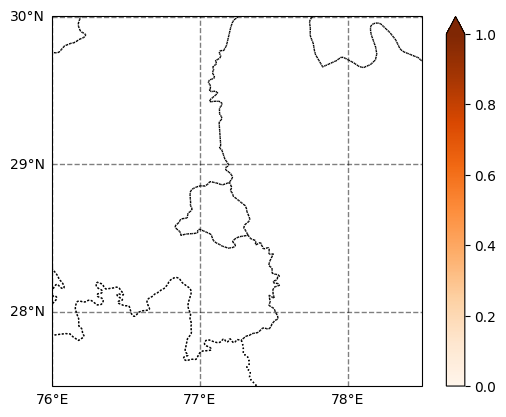

In [4]:
# Definir el bounding box (dominio):
n_lat_min = 27.5
n_lat_max = 30
n_lon_min = 76
n_lon_max = 78.5

# Definir la fecha y hora de inicio y de fin:
t_start = np.datetime64('2019-06-01 00:00:00')
t_end = np.datetime64('2019-08-31 23:59:59')

# Especificar la zona horaria local (esto será útil para la visualización posterior):
s_timezome = 'Asia/Calcutta'

# Veamos la región que seleccionamos para verificar que es la que queremos:
F_plot_map(n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max);


# Descarga de datos


## Descargar datos de SatPM

Este código descarga datos del dataset [SatPM V6.GL.03](https://www.satpm.org/v6-gl-03) para nuestra región y período de interés.
Alternativamente, podrías descargar manualmente los archivos desde el [sitio web de acceso a datos de SatPM](https://www.satpm.org/data-access) y volver a subirlos a tu Google Drive, pero este código ayuda a automatizar ese proceso y evita que tengas que descargar los archivos a tu computadora.


In [5]:
# Especificar la carpeta de tu drive donde se descargarán los datos:
s_folder_SatPM = '/content/drive/MyDrive/Colab Notebooks/ARSET/PM25_Training_2026/SatPM_Data'

# Descargar los datos para el rango de tiempo de interés:
l_files_SatPM = []
for t_month in np.arange(t_start.astype('datetime64[M]'),t_end.astype('datetime64[M]')+np.timedelta64(1,'M'),np.timedelta64(1,'M')):
  s_year = str(t_month)[0:4]
  s_month = str(t_month)[5:7]
  s_url = f'https://s3.amazonaws.com/satpmdata/V6GL03/FineResolution/GL/Monthly/{s_year}/V6GL03.CNNPM25.GL.{s_year}{s_month}-{s_year}{s_month}.nc'
  s_file = s_url.split('/')[-1]
  s_download_path = os.path.join(s_folder_SatPM,s_file)
  if os.path.exists(s_download_path):
    print(f'{s_file} ya fue descargado.')
  else:
    urllib.request.urlretrieve(s_url,s_download_path)
    print(f'Se descargo {s_url} en {s_folder_SatPM}')
  l_files_SatPM += [s_download_path]

# Combinar los datos en un solo archivo:
def F_time_from_SatPM_url(s_url):
  s_YYYYMM = s_url.split('.')[-2].split('-')[0]
  return np.datetime64(f'{s_YYYYMM[0:4]}-{s_YYYYMM[4:6]}-01 00:00:00')
a_data_SatPM = F_subset_and_combine(l_files_SatPM,n_lon_min,n_lat_min,n_lon_max,n_lat_max,t_start,t_end,F_time_from_file = F_time_from_SatPM_url)

# Filtrar los valores negativos:
a_data_SatPM['PM25_filtered'] = a_data_SatPM['PM25'].where(a_data_SatPM['PM25'] > 0)

# Guardar los datos para poder retomarlos más fácilmente en el futuro:
a_data_SatPM.to_netcdf(os.path.join(s_folder_SatPM,'SatPM_data_subset_homework.nc'))

# Observar el objeto de datos:
a_data_SatPM


V6GL03.CNNPM25.GL.201906-201906.nc ya fue descargado.
V6GL03.CNNPM25.GL.201907-201907.nc ya fue descargado.
V6GL03.CNNPM25.GL.201908-201908.nc ya fue descargado.


<xarray.Dataset> Size: 2MB
Dimensions:        (time: 3, lat: 250, lon: 250)
Coordinates:
  * time           (time) datetime64[s] 24B 2019-06-01 2019-07-01 2019-08-01
  * lat            (lat) float32 1kB 27.5 27.51 27.52 27.53 ... 29.98 29.99 30.0
  * lon            (lon) float32 1kB 76.0 76.01 76.03 76.04 ... 78.47 78.49 78.5
Data variables:
    PM25           (time, lat, lon) float32 750kB 46.02 45.15 ... 31.43 31.44
    PM25_filtered  (time, lat, lon) float32 750kB 46.02 45.15 ... 31.43 31.44
Attributes:
    TITLE:            Convolutional Neural Network Monthly PM2.5 Estimation o...
    CONTACT:          SIYUAN SHEN <s.siyuan@wustl.edu>
    LAT_DELTA:        0.01
    LON_DELTA:        0.01
    SPATIALCOVERAGE:  GL
    TIMECOVERAGE:     201906

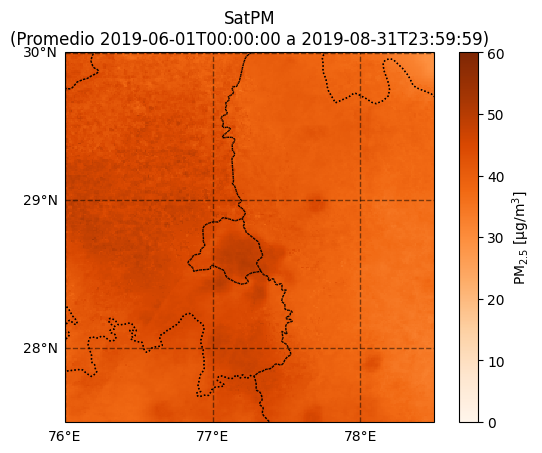

In [6]:
# Graficar los datos:
F_plot_map(a_data_plot = a_data_SatPM['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'SatPM\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,60]);


## Descargar datos de MERRA-2 CNN

Este código descarga datos del conjunto de datos [MERRA2_CNN_HAQAST_PM25](https://doi.org/10.5067/OCKK5HCFW5N3) para nuestra región y período de tiempo de interés.
Este código usa el paquete de Python [earthaccess](https://earthaccess.readthedocs.io/en/stable/) para automatizar la búsqueda y descarga de los datos.
Alternativamente, podrías descargar manualmente los archivos usando [Earthdata Search](https://search.earthdata.nasa.gov/search?q=MERRA2_CNN_HAQAST_PM25) y volver a subirlos a tu Google Drive, pero este código ayuda a automatizar ese proceso y evita que tengas que descargar los archivos a tu computadora.


In [7]:
# Especificar la carpeta de tu drive donde se descargarán los datos:
s_folder_MERRA2_CNN = '/content/drive/MyDrive/Colab Notebooks/ARSET/PM25_Training_2026/MERRA2_CNN_Data'

# Usar earthaccess para buscar los datos:
l_results = earthaccess.search_data(
    short_name='MERRA2_CNN_HAQAST_PM25',
    bounding_box=(n_lon_min,n_lat_min,n_lon_max,n_lat_max),
    temporal=(str(t_start),str(t_end))
)

# Usar earthaccess para descargar los datos:
l_files_MERRA2_CNN = earthaccess.download(l_results,s_folder_MERRA2_CNN)

# Combinar los datos en un solo archivo:
a_data_MERRA2_CNN = F_subset_and_combine(l_files_MERRA2_CNN,n_lon_min,n_lat_min,n_lon_max,n_lat_max,t_start,t_end)

# Filtrar los valores con banderas (flags) de baja calidad:
a_data_MERRA2_CNN['PM25_filtered'] = a_data_MERRA2_CNN['MERRA2_CNN_Surface_PM25'].where(a_data_MERRA2_CNN['QFLAG'] >= 3)

# Guardar los datos para poder retomarlos más fácilmente en el futuro:
a_data_MERRA2_CNN.to_netcdf(os.path.join(s_folder_MERRA2_CNN,'MERRA2_CNN_data_subset_homework.nc'))

# Observar el objeto de datos:
a_data_MERRA2_CNN


QUEUEING TASKS | :   0%|          | 0/92 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/92 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/92 [00:00<?, ?it/s]

<xarray.Dataset> Size: 866kB
Dimensions:                  (time: 2208, lat: 6, lon: 4)
Coordinates:
  * time                     (time) datetime64[ns] 18kB 2019-06-01T00:30:00 ....
  * lat                      (lat) float32 24B 27.5 28.0 28.5 29.0 29.5 30.0
  * lon                      (lon) float32 16B 76.25 76.88 77.5 78.12
Data variables:
    MERRA2_CNN_Surface_PM25  (time, lat, lon) float32 212kB 79.2 107.0 ... 42.29
    QFLAG                    (time, lat, lon) float64 424kB 4.0 4.0 ... 4.0 4.0
    PM25_filtered            (time, lat, lon) float32 212kB 79.2 107.0 ... 42.29
Attributes: (12/33)
    Comment:                           filename: MERRA2_HAQAST_CNN_L4_V1_2019...
    Filename:                          MERRA2_HAQAST_CNN_L4_V1_20190601.nc4
    Conventions:                       CF-1
    Institution:                       NASA Goddard Space Flight Center
    References:                        http://gmao.gsfc.nasa.gov ; https://do...
    Format:                            NetCDF-4/HDF-5
    ...                                ...
    RangeEndingDate:                   2019-06-01
    RangeEndingTime:                   23:59:59.000000
    DODS_EXTRA.Unlimited_Dimension:    time
    history:                           2023-04-21 04:24:38 GMT Hyrax-1.16.3 h...
    ProcessingLevel:                   4
    MapProjection:                     Geographic lat/lon. Datum: WGS-84

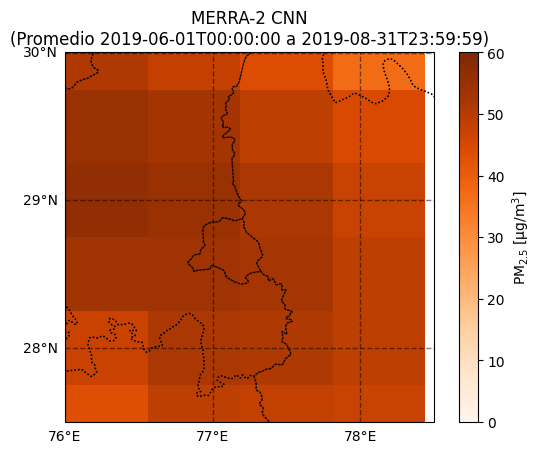

In [8]:
# Graficar los datos:
F_plot_map(a_data_plot = a_data_MERRA2_CNN['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'MERRA-2 CNN\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,60]);


## Descargar datos de monitores desde OpenAQ

Este código utiliza la [API de OpenAQ](https://docs.openaq.org/about/about) para buscar y descargar datos de monitoreo en superficie para nuestra región y período de tiempo de interés.

In [9]:
# Especificar la carpeta de tu drive donde se descargarán los datos:
s_folder_Main = '/content/drive/MyDrive/Colab Notebooks/ARSET/PM25_Training_2026'

# Usar OpenAQ para consultar los datos:
f_data_monitors = F_get_OpenAQ_from_API(n_lon_min,
                                        n_lat_min,
                                        n_lon_max,
                                        n_lat_max,
                                        t_start,
                                        t_end)

# Filtrar los valores menores que 0 y mayores que 1000:
f_data_monitors['PM25_filtered'] = f_data_monitors['PM2.5'].where((f_data_monitors['PM2.5'] > 0) & (f_data_monitors['PM2.5'] < 1000))

# Guardar los datos para poder retomarlos más fácilmente en el futuro:
f_data_monitors.to_csv(os.path.join(s_folder_Main,'Monitor_data_subset_homework.csv'))

# Ver el Data Object:
f_data_monitors

Consulta completada: Sensor 35, pagina 1.
Consulta completada: Sensor 12234787, pagina 1.
Consulta completada: Sensor 396, pagina 1.
Consulta completada: Sensor 12234796, pagina 1.
Consulta completada: Sensor 384, pagina 1.
Consulta completada: Sensor 12235610, pagina 1.
Consulta completada: Sensor 14258988, pagina 1.
Consulta completada: Sensor 1166, pagina 1.
Consulta completada: Sensor 1166, pagina 2.
Consulta completada: Sensor 1166, pagina 3.
Consulta completada: Sensor 1166, pagina 4.
Consulta completada: Sensor 1166, pagina 5.
Consulta completada: Sensor 14087, pagina 1.
Consulta completada: Sensor 12234702, pagina 1.
Consulta completada: Sensor 14521, pagina 1.
Consulta completada: Sensor 14912, pagina 1.
Consulta completada: Sensor 14912, pagina 2.
Consulta completada: Sensor 12234684, pagina 1.
Consulta completada: Sensor 14660, pagina 1.
Consulta completada: Sensor 14660, pagina 2.
Consulta completada: Sensor 14660, pagina 3.
Consulta completada: Sensor 14660, pagina 4.
Cons

PM2.5  PM25_filtered
lat       lon       time                                           
27.554793 76.611536 2019-06-18 22:52:30+00:00  10.56          10.56
                    2019-06-18 23:07:30+00:00  10.56          10.56
                    2019-06-18 23:22:30+00:00  13.73          13.73
                    2019-06-18 23:37:30+00:00  14.88          14.88
                    2019-06-18 23:52:30+00:00  14.88          14.88
...                                              ...            ...
29.966942 76.875879 2019-08-31 21:52:30+00:00  58.63          58.63
                    2019-08-31 22:22:30+00:00  56.77          56.77
                    2019-08-31 22:37:30+00:00  51.65          51.65
                    2019-08-31 22:52:30+00:00  51.65          51.65
                    2019-08-31 23:37:30+00:00  41.72          41.72

[270260 rows x 2 columns]

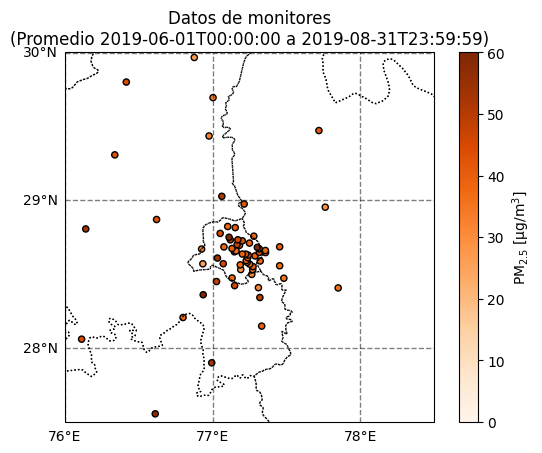

In [10]:
# Graficar los datos:
F_plot_map(a_data_plot_point = f_data_monitors['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'Datos de monitores\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,60]);


# Análisis

Ahora realizaremos algunos análisis de los datos a los que hemos accedido.


Primero, volvamos a cargar nuestros datos desde los archivos de subconjuntos guardados en Google Drive (esto es útil si retomas el análisis más adelante, para que no necesites volver a cargar todo el conjunto de datos).


In [11]:
# Volver a cargar los datos desde los subconjuntos guardados en tu Google Drive, si es necesario:
a_data_SatPM = xr.open_dataset(os.path.join(s_folder_SatPM,'SatPM_data_subset_homework.nc'))
a_data_MERRA2_CNN = xr.open_dataset(os.path.join(s_folder_MERRA2_CNN,'MERRA2_CNN_data_subset_homework.nc'))
f_data_monitors = pd.read_csv(os.path.join(s_folder_Main,'Monitor_data_subset_homework.csv'),index_col=[0,1,2])

## Comparación usando mapas

Hagamos dos gráficos de comparación, superponiendo los datos de los monitores en superficie como puntos sobre los mapas de los conjuntos de datos de SatPM y MERRA-2 CNN.


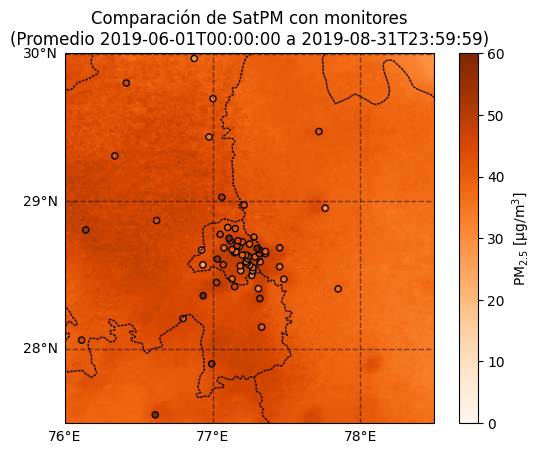

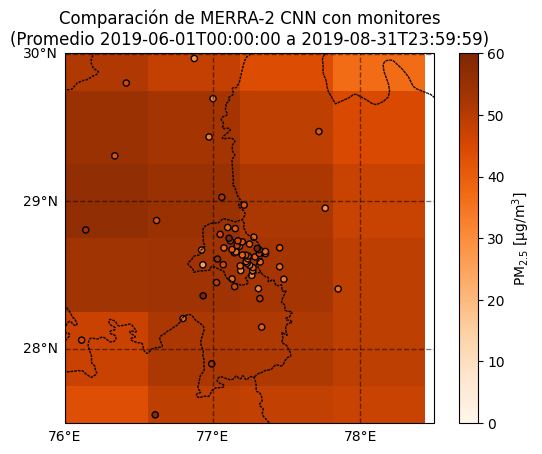

In [12]:
# Gráfico: comparar monitores en superficie con SatPM
F_plot_map(a_data_plot = a_data_SatPM['PM25_filtered'],
           a_data_plot_point = f_data_monitors['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'Comparación de SatPM con monitores\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,60]);

# Gráfico: comparar monitores en superficie con MERRA-2 CNN
F_plot_map(a_data_plot = a_data_MERRA2_CNN['PM25_filtered'],
           a_data_plot_point = f_data_monitors['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'Comparación de MERRA-2 CNN con monitores\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,60]);


## Comparación de promedios mensuales entre SatPM y monitores

Para comparar los datos de los monitores con la estimación de SatPM, primero debemos promediar los datos de los monitores a una escala temporal mensual, de modo que podamos comparar los valores directamente con los promedios mensuales del conjunto de datos de SatPM.

Uso `n_minimum_samples_per_month` para especificar un número mínimo de muestras horarias necesarias para calcular un promedio mensual; esto asegura que mi promedio sea representativo de todo el mes, y no solo de unos pocos días u horas.

Este código también guarda los datos promediados mensualmente resultantes en un archivo CSV, por si quiero revisarlos más adelante.


In [13]:
# Especificar el número mínimo de muestras válidas para calcular un promedio mensual:
n_minimum_samples_per_month = 24*20

# Crear un nuevo dataframe para ayudar a calcular los promedios mensuales:
f_data_monitors_monthly = f_data_monitors.copy().reset_index()
# Agregar una columna de tiempo con el inicio del mes:
f_data_monitors_monthly['time_month_start'] = [np.datetime64(t_time).astype('datetime64[M]') for t_time in f_data_monitors_monthly['time']]

# Calcular los promedios mensuales y las desviaciones estándar:
f_data_combined_monthly = f_data_monitors_monthly.groupby(['lat','lon','time_month_start'])[['PM25_filtered']].count().rename(columns={'PM25_filtered':'Count'})
f_data_combined_monthly['Average'] = f_data_monitors_monthly.groupby(['lat','lon','time_month_start'])[['PM25_filtered']].mean()
f_data_combined_monthly['StDev'] = f_data_monitors_monthly.groupby(['lat','lon','time_month_start'])[['PM25_filtered']].std()
# Conservar solo los promedios mensuales que cumplen el número mínimo de mediciones requeridas:
f_data_combined_monthly = f_data_combined_monthly.where(f_data_combined_monthly['Count'] >= n_minimum_samples_per_month)

# Agregar los datos mensuales de SatPM a este dataframe:
f_data_combined_monthly['SatPM'] = np.nan
for i_row in range(len(f_data_combined_monthly)):
  t_month = f_data_combined_monthly.index[i_row][2]
  n_lat = f_data_combined_monthly.index[i_row][0]
  n_lon = f_data_combined_monthly.index[i_row][1]
  f_data_combined_monthly.loc[(n_lat,n_lon,t_month),'SatPM'] = a_data_SatPM.sel(lat=n_lat,lon=n_lon,time=t_month,method='nearest')['PM25_filtered'].values

# Agregar los datos mensuales de MERRA-2 CNN a este dataframe:
f_data_combined_monthly['MERRA2_CNN'] = np.nan
for i_row in range(len(f_data_combined_monthly)):
  t_month = f_data_combined_monthly.index[i_row][2]
  n_lat = f_data_combined_monthly.index[i_row][0]
  n_lon = f_data_combined_monthly.index[i_row][1]
  f_data_combined_monthly.loc[(n_lat,n_lon,t_month),'MERRA2_CNN'] = a_data_MERRA2_CNN.sel(lat=n_lat,lon=n_lon,method='nearest')['PM25_filtered'].sel(time=slice(t_month,t_month+pd.DateOffset(months=1))).mean('time').values

# Guardar los resultados en un archivo CSV para referencia posterior:
f_data_combined_monthly.to_csv(os.path.join(s_folder_Main,'Combined_data_monthly_homework.csv'))

# Observar el dataframe resultante:
f_data_combined_monthly


Count    Average       StDev  \
lat       lon       time_month_start                                  
27.554793 76.611536 2019-06-01         877.0  48.982611   22.948410   
                    2019-07-01        2512.0  55.749025   89.136663   
                    2019-08-01        2364.0  62.214535  108.762040   
27.900200 76.993800 2019-06-01         924.0  63.616017   64.649419   
                    2019-07-01        1335.0  43.143288   37.915831   
...                                      ...        ...         ...   
29.800600 76.415500 2019-06-01         918.0  54.388464   23.105505   
                    2019-07-01        2525.0  52.072170   74.954838   
                    2019-08-01        2206.0  32.176655   19.413270   
29.966942 76.875879 2019-07-01        1644.0  31.854167   50.189759   
                    2019-08-01        2417.0  24.473620   10.855857   

                                          SatPM  MERRA2_CNN  
lat       lon       time_month_start                         
27.554793 76.611536 2019-06-01        46.703724   67.536438  
                    2019-07-01        42.375603   44.193054  
                    2019-08-01        42.627045   35.151947  
27.900200 76.993800 2019-06-01        49.464672   72.979546  
                    2019-07-01        46.900227   46.224106  
...                                         ...         ...  
29.800600 76.415500 2019-06-01        42.355347   72.375366  
                    2019-07-01        44.603085   46.745174  
                    2019-08-01        28.990160   34.615082  
29.966942 76.875879 2019-07-01        39.648926   43.589062  
                    2019-08-01        45.092556   33.250755  

[153 rows x 5 columns]

Ahora visualizo la comparación con un gráfico de dispersión y calculo algunas métricas de desempeño estándar.


Métricas de desempeño para SatPM
Estimated Mean: 44.9
Measured Mean: 43.3
Bias: 1.59
Mean Normalized Bias: 0.0367
RMSE: 11.5
Mean Normalized RMSE: 0.264
R^2: 0.193
Spatial Correlation: -0.00834 (-0.0518 to 0.336)
Temporal Correlation: 1 (-1 to 1)


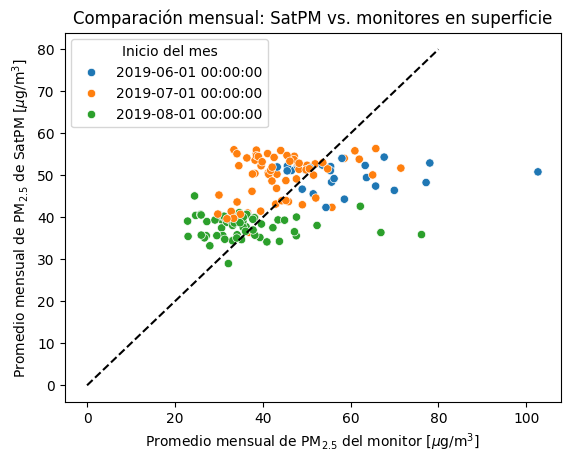

In [14]:
# Crear un gráfico de dispersión de comparación:
o_ax = sns.scatterplot(data=f_data_combined_monthly.dropna(),x='Average',y='SatPM',hue='time_month_start');
o_ax.plot([0,80],[0,80],'k--');
o_ax.legend(title='Inicio del mes')
o_ax.set_xlabel('Promedio mensual de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio mensual de PM$_{2.5}$ de SatPM [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación mensual: SatPM vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño:
print('Métricas de desempeño para SatPM')
F_compute_metrics(f_data_combined_monthly,
                  s_time = 'time_month_start',
                  s_value = 'Average',
                  s_estimate = 'SatPM');


Métricas de desempeño para MERRA-2 CNN (mensual)
Estimated Mean: 48.4
Measured Mean: 43.3
Bias: 4.95
Mean Normalized Bias: 0.114
RMSE: 11.7
Mean Normalized RMSE: 0.27
R^2: 0.161
Spatial Correlation: 0.217 (0.0629 to 0.345)
Temporal Correlation: 1 (-1 to 1)


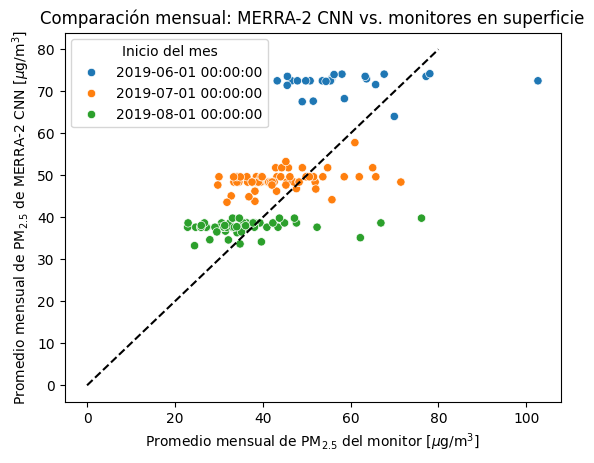

In [15]:
# Crear un gráfico de dispersión de comparación:
o_ax = sns.scatterplot(data=f_data_combined_monthly.dropna(),x='Average',y='MERRA2_CNN',hue='time_month_start');
o_ax.plot([0,80],[0,80],'k--');
o_ax.legend(title='Inicio del mes')
o_ax.set_xlabel('Promedio mensual de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio mensual de PM$_{2.5}$ de MERRA-2 CNN [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación mensual: MERRA-2 CNN vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño:
print('Métricas de desempeño para MERRA-2 CNN (mensual)')
F_compute_metrics(f_data_combined_monthly,
                  s_time = 'time_month_start',
                  s_value = 'Average',
                  s_estimate = 'MERRA2_CNN');


## Comparación de promedios horarios de MERRA-2 CNN y monitores

Para comparar los datos de los monitores con la estimación de MERRA-2 CNN, puedo hacer una comparación directa hora a hora, ya que ambos proporcionan datos horarios. Sin embargo, la resolución espacial es mucho más gruesa, donde una celda de la grilla de MERRA-2 usualmente cubre múltiples sitios. Por eso, primero quiero agregar los datos de los monitores a las celdas de la grilla de MERRA-2, para permitir una comparación directa.

Uso `n_minimum_samples_per_grid` para especificar un número mínimo de muestras de monitores necesarias para calcular un promedio en una celda de la grilla de MERRA-2; esto asegura que mi promedio sea representativo de varios monitores en la celda, y no solo de una ubicación específica.

Este código también guarda los datos en grilla resultantes en un archivo CSV, por si quiero revisarlos más adelante.


In [16]:
# Especificar el número mínimo de muestras válidas para calcular un promedio de celda:
n_minimum_samples_per_grid = 3

# Crear un nuevo dataframe para ayudar a calcular los promedios por celda:
f_data_monitors_gridded = f_data_monitors.copy().reset_index()

# Asignar los datos de los monitores a la celda más cercana de MERRA-2 (nota: la resolución de la grilla de MERRA-2 es 0.5 en latitud por 0.625 en longitud):
f_data_monitors_gridded['lat_grid'] = round(f_data_monitors_gridded['lat']/0.5)*0.5
f_data_monitors_gridded['lon_grid'] = round(f_data_monitors_gridded['lon']/0.625)*0.625

# Agrupar los datos por las celdas de latitud y longitud y agregar:
f_data_combined_gridded = f_data_monitors_gridded.groupby(['lat_grid','lon_grid','time'])[['PM25_filtered']].count().rename(columns={'PM25_filtered':'Count'})
f_data_combined_gridded['Average'] = f_data_monitors_gridded.groupby(['lat_grid','lon_grid','time'])[['PM25_filtered']].mean()
f_data_combined_gridded['StDev'] = f_data_monitors_gridded.groupby(['lat_grid','lon_grid','time'])[['PM25_filtered']].std()

# Filtrar los datos con menos del número requerido de muestras por celda:
f_data_combined_gridded = f_data_combined_gridded.where(f_data_combined_gridded['Count'] >= n_minimum_samples_per_grid).dropna()

# Agregar los datos horarios de MERRA-2 CNN a este dataframe (nota: también agrego columnas de hora del día y fecha local, para facilitar los pasos posteriores):
f_data_combined_gridded['MERRA2_CNN'] = np.nan
f_data_combined_gridded['local_day'] = np.nan
f_data_combined_gridded['local_hour_of_day'] = np.nan
for i_row in range(len(f_data_combined_gridded)):
  t_time = f_data_combined_gridded.index[i_row][2]
  n_lat = f_data_combined_gridded.index[i_row][0]
  n_lon = f_data_combined_gridded.index[i_row][1]
  f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'MERRA2_CNN'] = a_data_MERRA2_CNN.sel(lat=n_lat,lon=n_lon,time=np.datetime64(t_time.split('+')[0]),method='nearest')['PM25_filtered'].values
  f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'local_day'] = pd.to_datetime(t_time).tz_convert(s_timezome).date()
  f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'local_hour_of_day'] = pd.to_datetime(t_time).tz_convert(s_timezome).hour

# Guardar los resultados en un archivo CSV para referencia posterior:
f_data_combined_gridded.to_csv(os.path.join(s_folder_Main,'Combined_data_gridded_homework.csv'))

# Observar el dataframe resultante:
f_data_combined_gridded


Count    Average      StDev  \
lat_grid lon_grid time                                                     
28.5     76.875   2019-06-18 22:52:30+00:00    3.0  81.026667  22.493747   
                  2019-06-18 23:07:30+00:00    3.0  87.203333  34.470959   
                  2019-06-18 23:22:30+00:00    3.0  84.536667  37.066522   
                  2019-06-18 23:37:30+00:00    3.0  84.576667  37.039728   
                  2019-06-18 23:52:30+00:00    3.0  86.396667  35.940955   
...                                            ...        ...        ...   
29.0     76.875   2019-08-31 22:37:30+00:00    4.0  80.505000  37.245941   
                  2019-08-31 22:52:30+00:00    4.0  76.157500  39.991614   
                  2019-08-31 23:07:30+00:00    4.0  55.157500  18.658757   
                  2019-08-31 23:22:30+00:00    3.0  69.200000  43.133745   
                  2019-08-31 23:37:30+00:00    5.0  67.308000  33.321253   

                                             MERRA2_CNN   local_day  \
lat_grid lon_grid time                                                
28.5     76.875   2019-06-18 22:52:30+00:00   83.662178  2019-06-19   
                  2019-06-18 23:07:30+00:00   81.217216  2019-06-19   
                  2019-06-18 23:22:30+00:00   81.217216  2019-06-19   
                  2019-06-18 23:37:30+00:00   81.217216  2019-06-19   
                  2019-06-18 23:52:30+00:00   81.217216  2019-06-19   
...                                                 ...         ...   
29.0     76.875   2019-08-31 22:37:30+00:00   58.489651  2019-09-01   
                  2019-08-31 22:52:30+00:00   58.489651  2019-09-01   
                  2019-08-31 23:07:30+00:00   55.982697  2019-09-01   
                  2019-08-31 23:22:30+00:00   55.982697  2019-09-01   
                  2019-08-31 23:37:30+00:00   55.982697  2019-09-01   

                                             local_hour_of_day  
lat_grid lon_grid time                                          
28.5     76.875   2019-06-18 22:52:30+00:00                4.0  
                  2019-06-18 23:07:30+00:00                4.0  
                  2019-06-18 23:22:30+00:00                4.0  
                  2019-06-18 23:37:30+00:00                5.0  
                  2019-06-18 23:52:30+00:00                5.0  
...                                                        ...  
29.0     76.875   2019-08-31 22:37:30+00:00                4.0  
                  2019-08-31 22:52:30+00:00                4.0  
                  2019-08-31 23:07:30+00:00                4.0  
                  2019-08-31 23:22:30+00:00                4.0  
                  2019-08-31 23:37:30+00:00                5.0  

[17815 rows x 6 columns]

Ahora visualizo la comparación con un gráfico de dispersión y calculo algunas métricas de desempeño estándar.


Métricas de desempeño para MERRA-2 CNN (horario)
Estimated Mean: 45.1
Measured Mean: 44.1
Bias: 0.986
Mean Normalized Bias: 0.0224
RMSE: 22.7
Mean Normalized RMSE: 0.516
R^2: 0.319
Spatial Correlation: 0.612 (-1 to 1)
Temporal Correlation: 0.623 (0.352 to 0.859)


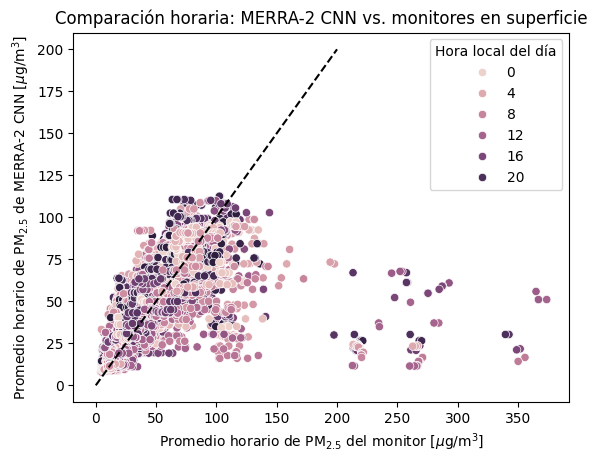

In [17]:
# Crear un gráfico de dispersión de comparación:
o_ax = sns.scatterplot(data=f_data_combined_gridded.dropna(),x='Average',y='MERRA2_CNN',hue='local_hour_of_day')
o_ax.plot([0,200],[0,200],'k--');
o_ax.legend(title='Hora local del día');
o_ax.set_xlabel('Promedio horario de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio horario de PM$_{2.5}$ de MERRA-2 CNN [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación horaria: MERRA-2 CNN vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño:
print('Métricas de desempeño para MERRA-2 CNN (horario)')
F_compute_metrics(f_data_combined_gridded,
                  s_time = 'time',
                  s_value = 'Average',
                  s_estimate = 'MERRA2_CNN');


Otra forma de evaluar estos resultados es comparar los patrones diurnos (es decir, el ciclo de 24 horas de las concentraciones) entre MERRA-2 CNN y los monitores.


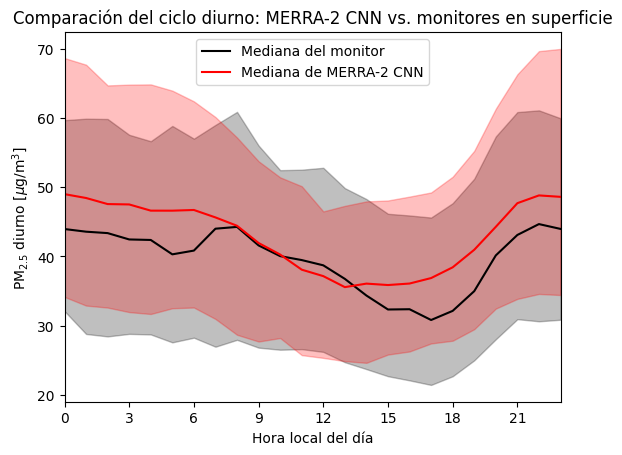

In [18]:
# Agrupar los datos de los monitores por hora local del día y calcular la mediana:
f_data_combined_gridded_by_timeofday = f_data_combined_gridded.groupby('local_hour_of_day')[['Average']].median()
# Agregar el conteo de muestras válidas:
f_data_combined_gridded_by_timeofday['Count'] = f_data_combined_gridded.groupby('local_hour_of_day')[['Average']].count()
# Agregar los percentiles 25 y 75 de los promedios horarios por hora del día, para dar una idea de la variabilidad:
f_data_combined_gridded_by_timeofday['75th_percentile'] = f_data_combined_gridded.groupby('local_hour_of_day')[['Average']].quantile(0.75)
f_data_combined_gridded_by_timeofday['25th_percentile'] = f_data_combined_gridded.groupby('local_hour_of_day')[['Average']].quantile(0.25)
# Repetir para el conjunto de datos de MERRA-2 CNN:
f_data_combined_gridded_by_timeofday['MERRA2_CNN'] = f_data_combined_gridded.groupby('local_hour_of_day')[['MERRA2_CNN']].median()
f_data_combined_gridded_by_timeofday['MERRA2_CNN_75th_percentile'] = f_data_combined_gridded.groupby('local_hour_of_day')[['MERRA2_CNN']].quantile(0.75)
f_data_combined_gridded_by_timeofday['MERRA2_CNN_25th_percentile'] = f_data_combined_gridded.groupby('local_hour_of_day')[['MERRA2_CNN']].quantile(0.25)

# Graficar los resultados:
o_fig = plt.figure()
o_ax = o_fig.add_subplot()
o_ax.fill_between(np.arange(0,24),f_data_combined_gridded_by_timeofday['25th_percentile'],f_data_combined_gridded_by_timeofday['75th_percentile'],color='black',alpha=0.25)
o_ax.fill_between(np.arange(0,24),f_data_combined_gridded_by_timeofday['MERRA2_CNN_25th_percentile'],f_data_combined_gridded_by_timeofday['MERRA2_CNN_75th_percentile'],color='red',alpha=0.25)
o_ax.plot(np.arange(0,24),f_data_combined_gridded_by_timeofday['Average'],color='black',label='Mediana del monitor')
o_ax.plot(np.arange(0,24),f_data_combined_gridded_by_timeofday['MERRA2_CNN'],color='red',label='Mediana de MERRA-2 CNN')
o_ax.legend();
o_ax.set_xlabel('Hora local del día');
o_ax.set_xticks([0,3,6,9,12,15,18,21])
o_ax.set_xlim([0,23])
o_ax.set_ylabel('PM$_{2.5}$ diurno [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación del ciclo diurno: MERRA-2 CNN vs. monitores en superficie');


## Comparación de promedios diarios de MERRA-2 CNN y monitores

Veamos si agregar los datos a promedios diarios en lugar de horarios cambia la comparación y las estadísticas.


Métricas de desempeño para MERRA-2 CNN (diario)
Estimated Mean: 46.3
Measured Mean: 45.4
Bias: 0.876
Mean Normalized Bias: 0.0193
RMSE: 12.9
Mean Normalized RMSE: 0.283
R^2: 0.57
Spatial Correlation: 0.84 (-1 to 1)
Temporal Correlation: 0.851 (0.555 to 0.948)


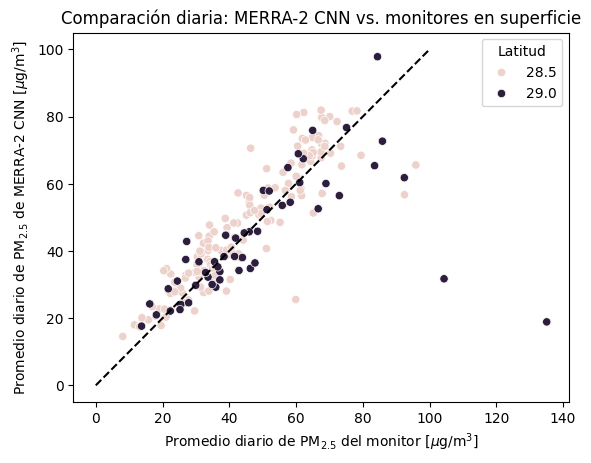

In [19]:
# Agregar los datos según el día local:
f_data_combined_gridded_daily = f_data_combined_gridded.groupby(['lat_grid','lon_grid','local_day'])[['Average','MERRA2_CNN']].mean()

# Crear un gráfico de dispersión de comparación:
o_ax = sns.scatterplot(data=f_data_combined_gridded_daily.dropna(),x='Average',y='MERRA2_CNN',hue='lat_grid');
o_ax.plot([0,100],[0,100],'k--');
o_ax.legend(title='Latitud');
o_ax.set_xlabel('Promedio diario de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio diario de PM$_{2.5}$ de MERRA-2 CNN [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación diaria: MERRA-2 CNN vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño:
print('Métricas de desempeño para MERRA-2 CNN (diario)')
F_compute_metrics(f_data_combined_gridded_daily,
                  s_time = 'local_day',
                  s_value = 'Average',
                  s_estimate = 'MERRA2_CNN');


## Ejemplo de un análisis usando umbrales de promedio diario

Podría ser de interés observar los datos donde las concentraciones están por encima o por debajo de un cierto umbral, para comparar el desempeño durante días "limpios" frente a días "contaminados". Aquí uso `n_threshold` para especificar un valor umbral de PM<sub>2.5</sub> para el promedio diario. Según si el promedio diario está por encima o por debajo del umbral, divido el conjunto de datos horarios en dos partes. Luego calculo las estadísticas solo para los valores donde el promedio diario está por debajo del umbral, por ejemplo, para examinar el desempeño en días "relativamente limpios".

**Para la tarea, utilice un umbral de 50 microgramos por metro cúbico.**


Métricas de desempeño para MERRA-2 CNN (valores por debajo del umbral):
Estimated Mean: 35.5
Measured Mean: 32.8
Bias: 2.65
Mean Normalized Bias: 0.0806
RMSE: 12.9
Mean Normalized RMSE: 0.392
R^2: 0.34
Spatial Correlation: 0.636 (-1 to 1)
Temporal Correlation: 0.612 (0.493 to 0.776)


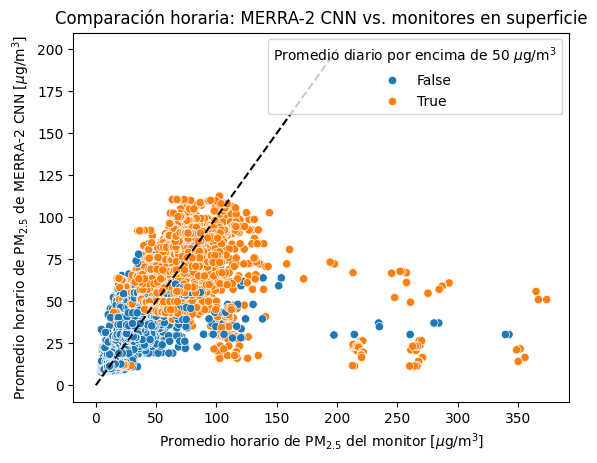

In [21]:
# Definir el umbral deseado para el análisis:
n_threshold = 50

# Identificar los valores horarios para los cuales el promedio diario está por encima o por debajo del umbral:
f_data_combined_gridded['Daily_Average_Above_Threshold'] = False
for i_row in range(len(f_data_combined_gridded)):
  n_lat = f_data_combined_gridded.index[i_row][0]
  n_lon = f_data_combined_gridded.index[i_row][1]
  t_time = f_data_combined_gridded.index[i_row][2]
  t_day = f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'local_day']
  n_daily_average = f_data_combined_gridded_daily.loc[(n_lat,n_lon,t_day),'Average']
  if n_daily_average > n_threshold:
    f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'Daily_Average_Above_Threshold'] = True

# Graficar los resultados:
o_ax = sns.scatterplot(data=f_data_combined_gridded.dropna(),x='Average',y='MERRA2_CNN',hue='Daily_Average_Above_Threshold')
o_ax.plot([0,200],[0,200],'k--');
o_ax.legend(title='Promedio diario por encima de '+str(n_threshold)+' $\\mu$g/m$^{3}$');
o_ax.set_xlabel('Promedio horario de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio horario de PM$_{2.5}$ de MERRA-2 CNN [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación horaria: MERRA-2 CNN vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño, considerando solo los datos por debajo del umbral:
print('Métricas de desempeño para MERRA-2 CNN (valores por debajo del umbral):')
F_compute_metrics(f_data_combined_gridded[f_data_combined_gridded['Daily_Average_Above_Threshold'] == False],
                  s_time = 'time',
                  s_value = 'Average',
                  s_estimate = 'MERRA2_CNN');


## Serie de tiempo para una ubicación

Finalmente, visualicemos estos datos diarios como una serie de tiempo para una ubicación. Esto se puede hacer restringiendo nuestro conjunto de datos solo a las coordenadas de una ubicación de interés. En el código de abajo, he especificado algunas ubicaciones de interés en nuestra región de estudio mediante sus coordenadas correspondientes en el conjunto de datos de MERRA-2 CNN. Se podría definir una lista personalizada de coordenadas de interés para tu región de estudio.

**Para la tarea, se han preconfigurado tres áreas que corresponden, a grandes rasgos, a las zonas este, oeste y norte de Nueva Delhi.**

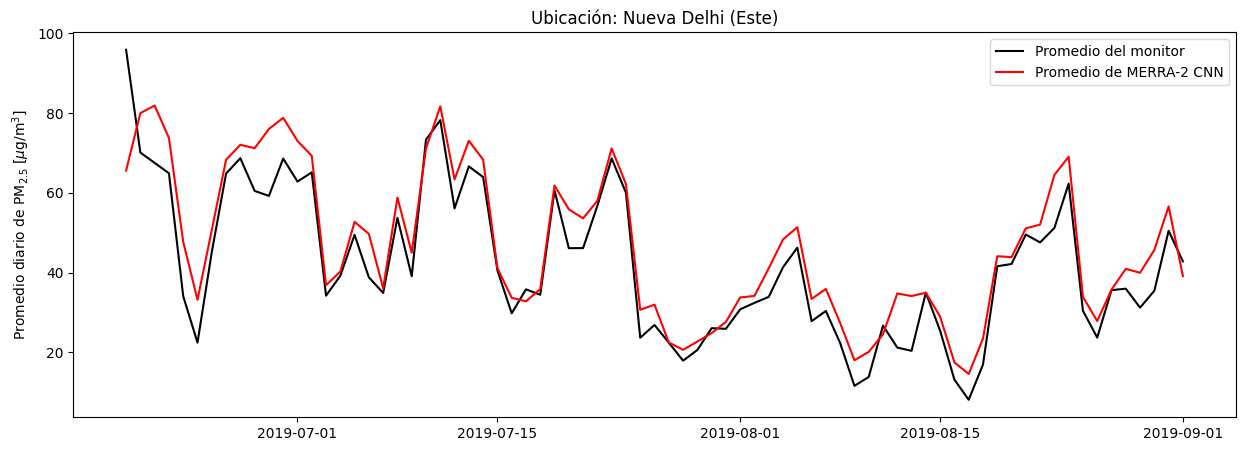

In [22]:
# Ubicaciones:
#   Nueva Delhi (Este):  lat 28.5, lon 77.5
#   Nueva Delhi (Oeste):  lat 28.5, lon 76.875
#   Nueva Delhi (Norte): lat 29.0, lon 76.875

# Esta es nuestra ubicación de interés
s_location = 'Nueva Delhi (Este)'

# Esta es una lista de ubicaciones de interés y sus coordenadas de celda correspondientes del conjunto de datos de MERRA-2 CNN:
d_location = {'Nueva Delhi (Este)':(28.5,77.5),
              'Nueva Delhi (Oeste)':(28.5,76.875),
              'Nueva Delhi (Norte)':(29.0,76.875),
              }

# Seleccionar solo los datos de la celda correspondiente a la ubicación de interés:
f_data_combined_gridded_daily_at_Location = f_data_combined_gridded_daily.loc[d_location[s_location]]

# Graficar la serie de tiempo:
o_fig = plt.figure(figsize=(15,5))
o_ax = o_fig.add_subplot()
o_ax.plot(f_data_combined_gridded_daily_at_Location.index,f_data_combined_gridded_daily_at_Location['Average'],color='black',label='Promedio del monitor')
o_ax.plot(f_data_combined_gridded_daily_at_Location.index,f_data_combined_gridded_daily_at_Location['MERRA2_CNN'],color='red',label='Promedio de MERRA-2 CNN')
o_ax.legend();
o_ax.set_ylabel('Promedio diario de PM$_{2.5}$ [$\\mu$g/m$^{3}$]');
o_ax.set_title(f'Ubicación: {s_location}');
